# Klasifikasi Lesi Kulit: Jinak (Benign) vs Ganas (Malignant)
### Harmonisasi Diagnosis dan Pemetaan Biner Dataset HAM10000, ISIC 2019, dan ISIC 2017

Notebook ini menggabungkan dan menyelaraskan label diagnosis dari 3 dataset utama, melakukan deduplikasi citra, lalu memetakan diagnosis ke dalam klasifikasi biner medis:
- **Jinak / Benign (0):** Lesi non-kanker yang aman (tahi lalat biasa, keratosis seboroik jinak, dermatofibroma, dan lesi vaskular).
- **Ganas / Malignant (1):** Kanker kulit atau lesi pra-kanker (melanoma, karsinoma sel basal, aktinik keratosis, dan karsinoma sel skuamosa).

Alur pengerjaan disusun terstruktur dalam 14 langkah kerja praktis dan dapat direproduksi secara utuh.

## Langkah 1: Setup Library dan Konfigurasi Dataset
Menyiapkan pustaka Python yang dibutuhkan dan mendefinisikan lokasi folder serta format ground truth untuk 6 partisi data dari HAM10000, ISIC 2019, dan ISIC 2017.

In [15]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

folder_aktif = os.getcwd()
if os.path.exists(os.path.join(folder_aktif, 'Dataset')):
    ROOT = os.path.join(folder_aktif, 'Dataset')
elif os.path.exists(os.path.join(os.path.dirname(folder_aktif), 'Dataset')):
    ROOT = os.path.join(os.path.dirname(folder_aktif), 'Dataset')
else:
    ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

print(f"Dataset root: {ROOT}")

SOURCES = {
    'ham10000': {
        'name': 'HAM10000', 'year': '2018', 'split': 'train', 'gt_format': 'ham_dx',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
    },
    'isic_2019_train': {
        'name': 'ISIC 2019 Training', 'year': '2019', 'split': 'train', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
    },
    'isic_2019_test': {
        'name': 'ISIC 2019 Test', 'year': '2019', 'split': 'test', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_GroundTruth.csv'),
    },
    'isic_2017_train': {
        'name': 'ISIC 2017 Training', 'year': '2017', 'split': 'train', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
    },
    'isic_2017_val': {
        'name': 'ISIC 2017 Validation', 'year': '2017', 'split': 'val', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
    },
    'isic_2017_test': {
        'name': 'ISIC 2017 Test', 'year': '2017', 'split': 'test', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
    },
}

print(f"Total dataset sumber: {len(SOURCES)}")

Dataset root: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset
Total dataset sumber: 6


## Langkah 2: Pemindaian File Gambar Fisik
Memindai dan mengindeks seluruh file citra berformat .jpg/.jpeg dari direktori masing-masing dataset.

In [16]:
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(d, f)
                        })
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(root_dir, f)
                        })

df_images = pd.DataFrame(all_images)
print(f"Gambar fisik terindeks : {len(df_images):,} citra")

Gambar fisik terindeks : 46,334 citra


## Langkah 3: Pemasangan Label Diagnosis dari File CSV
Membaca file ground truth dari masing-masing dataset untuk memasangkan diagnosis asli ke setiap file citra.

In [17]:
ground_truth_dfs = {}
source_label_maps = {}

for source, info in SOURCES.items():
    p = info.get('gt_path')
    fmt = info.get('gt_format')
    if not p or not os.path.exists(p):
        continue
    df_gt = pd.read_csv(p)
    id_col = next((c for c in ['image_id', 'image', 'image_name', 'isic_id'] if c in df_gt.columns), df_gt.columns[0])
    df_gt['image_id'] = df_gt[id_col].astype(str).str.replace('.jpg', '', regex=False)
    ground_truth_dfs[source] = df_gt
    
    m = {}
    if fmt == 'ham_dx':
        for _, row in df_gt.iterrows():
            m[row['image_id']] = str(row['dx']).lower()
    elif fmt == '2017':
        for _, row in df_gt.iterrows():
            if row.get('melanoma') == 1.0:
                m[row['image_id']] = 'melanoma'
            elif row.get('seborrheic_keratosis') == 1.0:
                m[row['image_id']] = 'seborrheic_keratosis'
            else:
                m[row['image_id']] = 'nevus'
    elif fmt == 'onehot9':
        cols = [c for c in df_gt.columns if c not in ('image_id', id_col, 'score_weight', 'validation_weight')]
        for _, row in df_gt.iterrows():
            assigned = None
            for c in cols:
                if row.get(c) == 1.0:
                    assigned = c
                    break
            if assigned:
                m[row['image_id']] = assigned
    source_label_maps[source] = m

df_images['original_label'] = df_images.apply(
    lambda r: source_label_maps.get(r['source'], {}).get(r['image_id']), 
    axis=1
)

print(f"Gambar berlabel CSV     : {df_images['original_label'].notna().sum():,} citra")

Gambar berlabel CSV     : 46,334 citra


## Langkah 4: Pembersihan Gambar Duplikat (Deduplikasi Data)
Menghapus gambar kembar antar-dataset dengan mempertahankan HAM10000 secara 100% utuh, diikuti ISIC 2019, lalu ISIC 2017, sesuai protokol Ichim et al. (MDPI Cancers 2023).

In [18]:
PRIORITY_ORDER = [
    'ham10000',
    'isic_2019_train',
    'isic_2019_test',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test'
]

priority_map = {src: i for i, src in enumerate(PRIORITY_ORDER)}
df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_map)

df_sorted = df_all.sort_values(by=['image_id', 'priority']).reset_index(drop=True)
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').reset_index(drop=True)
df_dropped = df_sorted[df_sorted.duplicated(subset=['image_id'], keep='first')].reset_index(drop=True)

clean_keeper_map = dict(zip(df_clean['image_id'], df_clean['source']))
df_dropped['kept_by'] = df_dropped['image_id'].map(clean_keeper_map)

before_counts = df_all['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_dedup = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct = (a / b * 100) if b > 0 else 0
    sub = df_dropped[df_dropped['source'] == src]
    if d == 0:
        dup_target = "- (Data primer utuh)"
    else:
        target_counts = sub['kept_by'].value_counts().to_dict()
        dup_target = ", ".join([f"{k} ({v:,})" for k, v in target_counts.items()])
    rows_dedup.append({
        'Source Dataset': src,
        'Before (Mentah)': f"{b:,}",
        'Duplikat Dibuang': f"{d:,}",
        'Duplikat dengan Dataset Mana': dup_target,
        'After (Bersih)': f"{a:,}",
        'Persentase Bertahan': f"{pct:.1f}%"
    })

df_dedup_summary = pd.DataFrame(rows_dedup)
display(df_dedup_summary)

print(f"Total data mentah : {len(df_all):,} citra")
print(f"Duplikat dibuang  : {len(df_dropped):,} citra")
print(f"Total data bersih : {len(df_clean):,} citra")

,Source Dataset,Before (Mentah),Duplikat Dibuang,Duplikat dengan Dataset Mana,After (Bersih),Persentase Bertahan
0,ham10000,"10,015",0,- (Data primer utuh),"10,015",100.0%
1,isic_2019_train,"25,331","10,015","ham10000 (10,015)","15,316",60.5%
2,isic_2019_test,"8,238",0,- (Data primer utuh),"8,238",100.0%
3,isic_2017_train,"2,000",717,isic_2019_train (717),"1,283",64.1%
4,isic_2017_val,150,2,isic_2019_train (2),148,98.7%
5,isic_2017_test,600,1,isic_2019_train (1),599,99.8%


Total data mentah : 46,334 citra
Duplikat dibuang  : 10,735 citra
Total data bersih : 35,599 citra


## Langkah 5: Eksplorasi Kelas Diagnosis Asli Tiap Dataset
Melihat daftar diagnosis bawaan pada masing-masing dataset sebelum dilakukan penyelarasan istilah medis.

In [19]:
# 1. Diagnosis Asli HAM10000 (7 Kelas)
HAM_INFO = {
    'nv': ('Melanocytic Nevus', 'Tahi lalat melanositik'),
    'mel': ('Melanoma', 'Kanker kulit melanosit'),
    'bkl': ('Benign Keratosis', 'Keratosis seboroik / solar lentigo'),
    'bcc': ('Basal Cell Carcinoma', 'Karsinoma sel basal'),
    'akiec': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik (Bowen)'),
    'vasc': ('Vascular Lesion', 'Lesi vaskular (cherry angioma/hemangioma)'),
    'df': ('Dermatofibroma', 'Nodul jinak jaringan ikat kulit')
}

ham_sub = df_clean[df_clean['source'] == 'ham10000']
ham_freq = ham_sub['original_label'].value_counts()
rows_ham = []
for lbl, cnt in ham_freq.items():
    dname, desc = HAM_INFO.get(lbl, (lbl.upper(), '-'))
    rows_ham.append({
        'Label Asli': lbl,
        'Nama Medis': dname,
        'Keterangan Medis': desc,
        'Jumlah Sampel': f"{cnt:,}",
        'Proporsi': f"{cnt / len(ham_sub) * 100:.2f}%"
    })
df_ham_classes = pd.DataFrame(rows_ham)
print("Diagnosis Asli HAM10000 (7 Kelas):")
display(df_ham_classes)

# 2. Diagnosis Asli ISIC 2019 (9 Kelas: 8 Target + 1 UNK)
ISIC19_INFO = {
    'NV': ('Melanocytic Nevus', 'Tahi lalat melanositik'),
    'MEL': ('Melanoma', 'Kanker melanosit'),
    'BCC': ('Basal Cell Carcinoma', 'Karsinoma sel basal'),
    'BKL': ('Benign Keratosis', 'Keratosis seboroik'),
    'AK': ('Actinic Keratosis', 'Lesi pra-kanker keratinositik'),
    'SCC': ('Squamous Cell Carcinoma', 'Karsinoma sel skuamosa'),
    'VASC': ('Vascular Lesion', 'Lesi vaskular'),
    'DF': ('Dermatofibroma', 'Nodul jinak kulit'),
    'UNK': ('Unknown', 'Label out-of-distribution (khusus uji)')
}

isic19_sub = df_clean[df_clean['source'].isin(['isic_2019_train', 'isic_2019_test'])]
isic19_tr_sub = df_clean[df_clean['source'] == 'isic_2019_train']
isic19_te_sub = df_clean[df_clean['source'] == 'isic_2019_test']

c19_all = isic19_sub['original_label'].value_counts()
rows_19 = []
for lbl, cnt in c19_all.items():
    dname, desc = ISIC19_INFO.get(lbl, (lbl, '-'))
    c_tr = (isic19_tr_sub['original_label'] == lbl).sum()
    c_te = (isic19_te_sub['original_label'] == lbl).sum()
    rows_19.append({
        'Label Asli': lbl,
        'Nama Medis': dname,
        'Keterangan Medis': desc,
        'Train (Bersih)': f"{c_tr:,}",
        'Test (Bersih)': f"{c_te:,}",
        'Total ISIC 2019': f"{cnt:,}",
        'Proporsi': f"{cnt / len(isic19_sub) * 100:.2f}%"
    })
df_isic19_classes = pd.DataFrame(rows_19)
print("\nDiagnosis Asli ISIC 2019 (9 Kelas):")
display(df_isic19_classes)

# 3. Diagnosis Asli ISIC 2017 (3 Kelas)
ISIC17_INFO = {
    'nevus': ('Melanocytic Nevus', 'Tahi lalat melanositik'),
    'melanoma': ('Melanoma', 'Kanker kulit melanosit'),
    'seborrheic_keratosis': ('Seborrheic Keratosis', 'Keratosis seboroik')
}

isic17_sub = df_clean[df_clean['source'].isin(['isic_2017_train', 'isic_2017_val', 'isic_2017_test'])]
c17_all = isic17_sub['original_label'].value_counts()
rows_17 = []
for lbl, cnt in c17_all.items():
    dname, desc = ISIC17_INFO.get(lbl, (lbl, '-'))
    c_tr = (df_clean[df_clean['source'] == 'isic_2017_train']['original_label'] == lbl).sum()
    c_va = (df_clean[df_clean['source'] == 'isic_2017_val']['original_label'] == lbl).sum()
    c_te = (df_clean[df_clean['source'] == 'isic_2017_test']['original_label'] == lbl).sum()
    rows_17.append({
        'Label Asli': lbl,
        'Nama Medis': dname,
        'Keterangan Medis': desc,
        'Train (17)': f"{c_tr:,}",
        'Val (17)': f"{c_va:,}",
        'Test (17)': f"{c_te:,}",
        'Total ISIC 2017': f"{cnt:,}",
        'Proporsi': f"{cnt / len(isic17_sub) * 100:.2f}%"
    })
df_isic17_classes = pd.DataFrame(rows_17)
print("\nDiagnosis Asli ISIC 2017 (3 Kelas):")
display(df_isic17_classes)

Diagnosis Asli HAM10000 (7 Kelas):


,Label Asli,Nama Medis,Keterangan Medis,Jumlah Sampel,Proporsi
0,nv,Melanocytic Nevus,Tahi lalat melanositik,"6,705",66.95%
1,mel,Melanoma,Kanker kulit melanosit,"1,113",11.11%
2,bkl,Benign Keratosis,Keratosis seboroik / solar lentigo,"1,099",10.97%
3,bcc,Basal Cell Carcinoma,Karsinoma sel basal,514,5.13%
4,akiec,Actinic Keratosis,Lesi pra-kanker keratinositik (Bowen),327,3.27%
5,vasc,Vascular Lesion,Lesi vaskular (cherry angioma/hemangioma),142,1.42%
6,df,Dermatofibroma,Nodul jinak jaringan ikat kulit,115,1.15%



Diagnosis Asli ISIC 2019 (9 Kelas):


,Label Asli,Nama Medis,Keterangan Medis,Train (Bersih),Test (Bersih),Total ISIC 2019,Proporsi
0,NV,Melanocytic Nevus,Tahi lalat melanositik,"6,170","2,495","8,665",36.79%
1,MEL,Melanoma,Kanker melanosit,"3,409","1,327","4,736",20.11%
2,BCC,Basal Cell Carcinoma,Karsinoma sel basal,"2,809",975,"3,784",16.07%
3,BKL,Benign Keratosis,Keratosis seboroik,"1,525",660,"2,185",9.28%
4,UNK,Unknown,Label out-of-distribution (khusus uji),0,"2,047","2,047",8.69%
5,AK,Actinic Keratosis,Lesi pra-kanker keratinositik,737,374,"1,111",4.72%
6,SCC,Squamous Cell Carcinoma,Karsinoma sel skuamosa,431,165,596,2.53%
7,DF,Dermatofibroma,Nodul jinak kulit,124,91,215,0.91%
8,VASC,Vascular Lesion,Lesi vaskular,111,104,215,0.91%



Diagnosis Asli ISIC 2017 (3 Kelas):


,Label Asli,Nama Medis,Keterangan Medis,Train (17),Val (17),Test (17),Total ISIC 2017,Proporsi
0,nevus,Melanocytic Nevus,Tahi lalat melanositik,804,76,393,"1,273",62.71%
1,seborrheic_keratosis,Seborrheic Keratosis,Keratosis seboroik,252,42,90,384,18.92%
2,melanoma,Melanoma,Kanker kulit melanosit,227,30,116,373,18.37%


## Langkah 6: Harmonisasi Label Medis Internasional
Menyeragamkan sinonim dan variasi penulisan diagnosis ke dalam 8 singkatan internasional resmi konsorsium ISIC, mengacu pada standar ontologi Tschandl et al. (Nature Sci Data 2018) dan Codella et al. (IEEE ISBI 2018).

In [20]:
LABEL_HARMONIZATION = {
    'nv': 'NV', 'nevus': 'NV', 'NV': 'NV',
    'mel': 'MEL', 'melanoma': 'MEL', 'MEL': 'MEL',
    'bkl': 'BKL', 'seborrheic_keratosis': 'BKL', 'BKL': 'BKL',
    'bcc': 'BCC', 'BCC': 'BCC',
    'akiec': 'AKIEC', 'ak': 'AKIEC', 'AK': 'AKIEC',
    'vasc': 'VASC', 'VASC': 'VASC',
    'df': 'DF', 'DF': 'DF',
    'scc': 'SCC', 'SCC': 'SCC',
    'unk': 'UNK', 'UNK': 'UNK'
}

UNIFIED_DIAGNOSIS_NAME = {
    'NV': 'Melanocytic Nevus',
    'MEL': 'Melanoma',
    'BCC': 'Basal Cell Carcinoma',
    'BKL': 'Benign Keratosis (Seborrheic Keratosis / Solar Lentigo)',
    'AKIEC': 'Actinic Keratosis / Bowen Disease',
    'SCC': 'Squamous Cell Carcinoma',
    'VASC': 'Vascular Lesion',
    'DF': 'Dermatofibroma',
    'UNK': 'Unknown (Out of Distribution)'
}

df_clean['unified_class'] = df_clean['original_label'].map(LABEL_HARMONIZATION)

def get_dataset_family(src):
    if 'ham10000' in src:
        return 'HAM10000'
    elif '2019' in src:
        return 'ISIC 2019'
    elif '2017' in src:
        return 'ISIC 2017'
    return src

df_clean['dataset_family'] = df_clean['source'].apply(get_dataset_family)

ORDERED_CLASSES = ['NV', 'MEL', 'BCC', 'BKL', 'AKIEC', 'SCC', 'VASC', 'DF', 'UNK']
crosstab_raw = pd.crosstab(df_clean['unified_class'], df_clean['dataset_family'])

crosstab_rows = []
tot_clean = len(df_clean)
for cls in ORDERED_CLASSES:
    if cls in crosstab_raw.index:
        n_ham = int(crosstab_raw.loc[cls, 'HAM10000']) if 'HAM10000' in crosstab_raw.columns else 0
        n_19  = int(crosstab_raw.loc[cls, 'ISIC 2019']) if 'ISIC 2019' in crosstab_raw.columns else 0
        n_17  = int(crosstab_raw.loc[cls, 'ISIC 2017']) if 'ISIC 2017' in crosstab_raw.columns else 0
        n_tot = n_ham + n_19 + n_17
        crosstab_rows.append({
            'Kelas (Harmonisasi)': cls,
            'Nama Diagnosis Medis': UNIFIED_DIAGNOSIS_NAME.get(cls, cls),
            'HAM10000': f"{n_ham:,}",
            'ISIC 2019': f"{n_19:,}",
            'ISIC 2017': f"{n_17:,}",
            'Total Bersih': f"{n_tot:,}",
            '% Proporsi': f"{n_tot / tot_clean * 100:.2f}%"
        })

crosstab_rows.append({
    'Kelas (Harmonisasi)': 'TOTAL BERSIH',
    'Nama Diagnosis Medis': 'Seluruh Kelas (Pra-Drop UNK)',
    'HAM10000': f"{(df_clean['dataset_family'] == 'HAM10000').sum():,}",
    'ISIC 2019': f"{(df_clean['dataset_family'] == 'ISIC 2019').sum():,}",
    'ISIC 2017': f"{(df_clean['dataset_family'] == 'ISIC 2017').sum():,}",
    'Total Bersih': f"{tot_clean:,}",
    '% Proporsi': '100.0%'
})

df_unified_matrix = pd.DataFrame(crosstab_rows)
display(df_unified_matrix)

,Kelas (Harmonisasi),Nama Diagnosis Medis,HAM10000,ISIC 2019,ISIC 2017,Total Bersih,% Proporsi
0,NV,Melanocytic Nevus,"6,705","8,665","1,273","16,643",46.75%
1,MEL,Melanoma,"1,113","4,736",373,"6,222",17.48%
2,BCC,Basal Cell Carcinoma,514,"3,784",0,"4,298",12.07%
3,BKL,Benign Keratosis (Seborrheic Keratosis / Solar...,"1,099","2,185",384,"3,668",10.30%
4,AKIEC,Actinic Keratosis / Bowen Disease,327,"1,111",0,"1,438",4.04%
5,SCC,Squamous Cell Carcinoma,0,596,0,596,1.67%
6,VASC,Vascular Lesion,142,215,0,357,1.00%
7,DF,Dermatofibroma,115,215,0,330,0.93%
8,UNK,Unknown (Out of Distribution),0,"2,047",0,"2,047",5.75%
9,TOTAL BERSIH,Seluruh Kelas (Pra-Drop UNK),"10,015","23,554","2,030","35,599",100.0%


## Langkah 7: Visualisasi Distribusi Kelas Terharmonisasi
Menampilkan grafik sebaran 8 kelas medis terharmonisasi secara keseluruhan dan rincian proporsi kontribusi dari masing-masing dataset sumber.

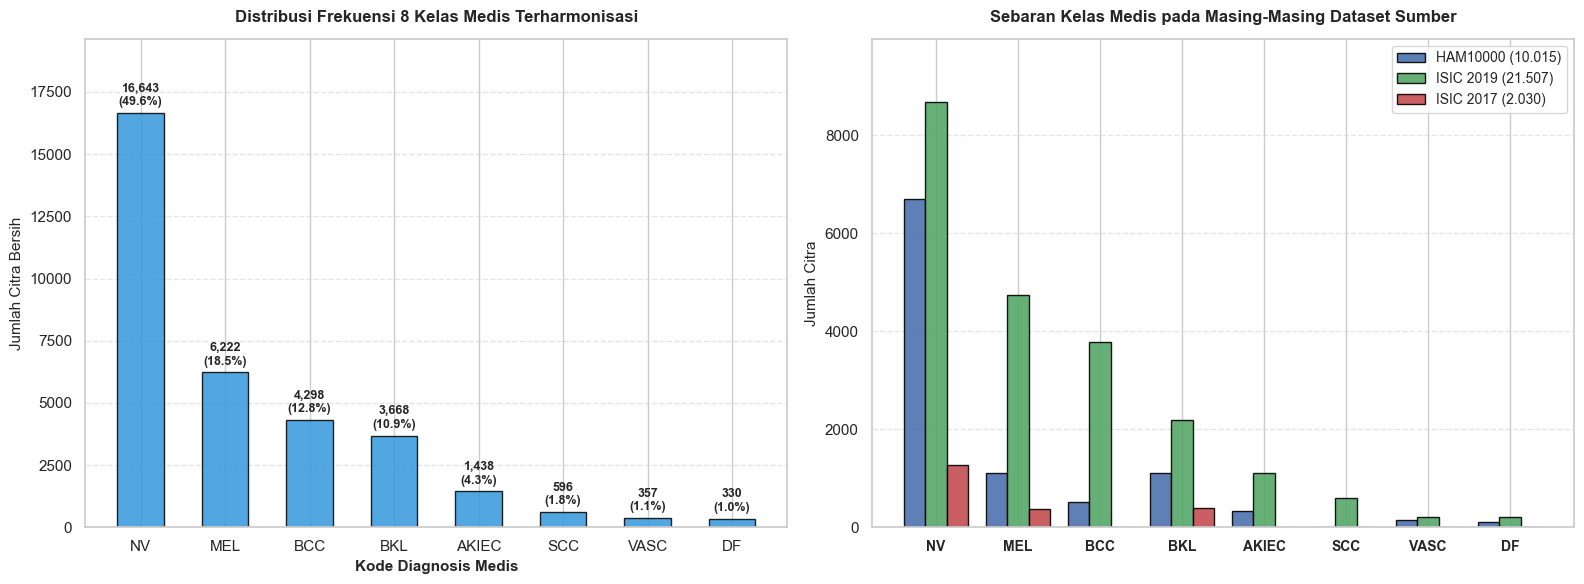

In [21]:
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))

valid_classes = [c for c in ORDERED_CLASSES if c != 'UNK']
cls_counts_valid = [int((df_clean['unified_class'] == c).sum()) for c in valid_classes]

bars = axes1[0].bar(valid_classes, cls_counts_valid, color='#3498db', edgecolor='black', alpha=0.85, width=0.55)
axes1[0].set_title("Distribusi Frekuensi 8 Kelas Medis Terharmonisasi", fontsize=12, fontweight='bold', pad=12)
axes1[0].set_ylabel("Jumlah Citra Bersih", fontsize=11)
axes1[0].set_xlabel("Kode Diagnosis Medis", fontsize=11, fontweight='bold')
axes1[0].set_ylim(0, max(cls_counts_valid) * 1.18)
axes1[0].grid(axis='y', linestyle='--', alpha=0.5)

for b in bars:
    h = b.get_height()
    pct = h / sum(cls_counts_valid) * 100
    axes1[0].text(b.get_x() + b.get_width()/2.0, h + 200, f"{int(h):,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')

x_pos = np.arange(len(valid_classes))
width_b = 0.26

ham_vals = [int(((df_clean['dataset_family'] == 'HAM10000') & (df_clean['unified_class'] == c)).sum()) for c in valid_classes]
isic19_vals = [int(((df_clean['dataset_family'] == 'ISIC 2019') & (df_clean['unified_class'] == c)).sum()) for c in valid_classes]
isic17_vals = [int(((df_clean['dataset_family'] == 'ISIC 2017') & (df_clean['unified_class'] == c)).sum()) for c in valid_classes]

axes1[1].bar(x_pos - width_b, ham_vals, width=width_b, label='HAM10000 (10.015)', color='#4c72b0', edgecolor='black', alpha=0.9)
axes1[1].bar(x_pos, isic19_vals, width=width_b, label='ISIC 2019 (21.507)', color='#55a868', edgecolor='black', alpha=0.9)
axes1[1].bar(x_pos + width_b, isic17_vals, width=width_b, label='ISIC 2017 (2.030)', color='#c44e52', edgecolor='black', alpha=0.9)

axes1[1].set_xticks(x_pos)
axes1[1].set_xticklabels(valid_classes, fontsize=10, fontweight='bold')
axes1[1].set_ylabel("Jumlah Citra", fontsize=11)
axes1[1].set_title("Sebaran Kelas Medis pada Masing-Masing Dataset Sumber", fontsize=12, fontweight='bold', pad=12)
axes1[1].legend(fontsize=10)
axes1[1].set_ylim(0, max(max(ham_vals), max(isic19_vals)) * 1.15)
axes1[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Langkah 8: Rujukan Ilmiah dan Konsensus Medis untuk Pemetaan Biner
Mengkaji literatur ilmiah bereputasi internasional (Nature, IEEE, Elsevier, MDPI) untuk menentukan landasan medis pengelompokan 8 penyakit ke dalam kategori Jinak (Benign) vs Ganas (Malignant).

In [22]:
# 1. Rujukan Paper Primer & Pemetaan Biner Utama
df_main_ref = pd.DataFrame([
    {
        'Dataset': 'ISIC 2017',
        'Paper Primer (Multiclass)': 'Codella et al. (IEEE ISBI 2018)',
        'Rujukan Pemetaan Biner': 'Catarina Barata et al. (Elsevier Q1 2020)',
        'Benign (0)': 'nevus (NV), seborrheic_keratosis (BKL)',
        'Malignant (1)': 'melanoma (MEL)'
    },
    {
        'Dataset': 'HAM10000',
        'Paper Primer (Multiclass)': 'Tschandl et al. (Nature Sci Data 2018)',
        'Rujukan Pemetaan Biner': 'Ioannis Kousis et al. (MDPI Electronics 2022)',
        'Benign (0)': 'nv, bkl, df, vasc',
        'Malignant (1)': 'mel, bcc, akiec'
    },
    {
        'Dataset': 'ISIC 2019',
        'Paper Primer (Multiclass)': 'Combalia et al. (arXiv / ISIC 2019)',
        'Rujukan Pemetaan Biner': 'MorphoNet / Yao et al. (MDPI 2026)',
        'Benign (0)': 'NV, BKL, DF, VASC',
        'Malignant (1)': 'MEL, BCC, AKIEC, SCC'
    }
])
print("Rujukan Paper Primer & Pemetaan Biner:")
display(df_main_ref)

# 2. Rekapitulasi 8 Literatur Pendukung
df_lit = pd.DataFrame([
    {'Dataset': 'ISIC 2017', 'Paper': 'Barata et al. (2020)', 'Penerbit': 'Elsevier', 'Benign': 'nevus, seborrheic_keratosis', 'Malignant': 'melanoma'},
    {'Dataset': 'ISIC 2017', 'Paper': 'Jojoa Acosta et al. (2021)', 'Penerbit': 'Springer', 'Benign': 'Nevus, Seborrheic Keratosis', 'Malignant': 'Melanoma'},
    {'Dataset': 'HAM10000', 'Paper': 'Harangi et al. (2020)', 'Penerbit': 'Elsevier', 'Benign': 'bkl, df, nv', 'Malignant': 'mel, bcc, akiec, vasc*'},
    {'Dataset': 'HAM10000', 'Paper': 'Kousis et al. (2022)', 'Penerbit': 'MDPI', 'Benign': 'nv, bkl, vasc, df', 'Malignant': 'mel, bcc, akiec'},
    {'Dataset': 'HAM10000', 'Paper': 'SkinNet-16 / Ghosh (2022)', 'Penerbit': 'Frontiers', 'Benign': 'df, bkl, vasc, nv', 'Malignant': 'bcc, mel, akiec'},
    {'Dataset': 'HAM10000', 'Paper': 'Ameri (2020)', 'Penerbit': 'JBPE', 'Benign': 'df, nv, bkl', 'Malignant': 'mel, bcc, akiec (vasc exclude)'},
    {'Dataset': 'ISIC 2019', 'Paper': 'MorphoNet / Yao (2026)', 'Penerbit': 'MDPI', 'Benign': 'NV, BKL, DF, VASC', 'Malignant': 'MEL, BCC, AKIEC, SCC'},
    {'Dataset': 'ISIC 2019', 'Paper': 'Venugopal et al. (2023)', 'Penerbit': 'Elsevier', 'Benign': 'NV, BKL, AK*, UNK', 'Malignant': 'MEL, BCC, SCC'}
])
print("\nRekapitulasi Literatur Pendukung:")
display(df_lit)

# 3. Hasil Konsensus Voting & Catatan Medis
df_voting = pd.DataFrame([
    {'Kelas': 'NV (Nevus)', 'Suara Benign': '8 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Tahi lalat biasa (non-kanker)'},
    {'Kelas': 'BKL (Keratosis)', 'Suara Benign': '8 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Keratosis seboroik jinak'},
    {'Kelas': 'DF', 'Suara Benign': '5 (100%)', 'Suara Malignant': '0 (0%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Dermatofibroma jinak'},
    {'Kelas': 'VASC', 'Suara Benign': '4 (80%)', 'Suara Malignant': '1 (20%)', 'Target': 'Benign (0)', 'Catatan Medis': 'Lesi vaskular jinak (cherry angioma/hemangioma)'},
    {'Kelas': 'MEL (Melanoma)', 'Suara Benign': '0 (0%)', 'Suara Malignant': '8 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Kanker melanoma ganas'},
    {'Kelas': 'BCC', 'Suara Benign': '0 (0%)', 'Suara Malignant': '6 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Karsinoma sel basal ganas'},
    {'Kelas': 'SCC', 'Suara Benign': '0 (0%)', 'Suara Malignant': '2 (100%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Karsinoma sel skuamosa ganas'},
    {'Kelas': 'AKIEC / AK', 'Suara Benign': '1 (17%)', 'Suara Malignant': '5 (83%)', 'Target': 'Malignant (1)', 'Catatan Medis': 'Lesi pra-kanker (Bowen disease / karsinoma in situ)'}
])
print("\nHasil Konsensus Voting Medis:")
display(df_voting)

Rujukan Paper Primer & Pemetaan Biner:


,Dataset,Paper Primer (Multiclass),Rujukan Pemetaan Biner,Benign (0),Malignant (1)
0,ISIC 2017,Codella et al. (IEEE ISBI 2018),Catarina Barata et al. (Elsevier Q1 2020),"nevus (NV), seborrheic_keratosis (BKL)",melanoma (MEL)
1,HAM10000,Tschandl et al. (Nature Sci Data 2018),Ioannis Kousis et al. (MDPI Electronics 2022),"nv, bkl, df, vasc","mel, bcc, akiec"
2,ISIC 2019,Combalia et al. (arXiv / ISIC 2019),MorphoNet / Yao et al. (MDPI 2026),"NV, BKL, DF, VASC","MEL, BCC, AKIEC, SCC"



Rekapitulasi Literatur Pendukung:


,Dataset,Paper,Penerbit,Benign,Malignant
0,ISIC 2017,Barata et al. (2020),Elsevier,"nevus, seborrheic_keratosis",melanoma
1,ISIC 2017,Jojoa Acosta et al. (2021),Springer,"Nevus, Seborrheic Keratosis",Melanoma
2,HAM10000,Harangi et al. (2020),Elsevier,"bkl, df, nv","mel, bcc, akiec, vasc*"
3,HAM10000,Kousis et al. (2022),MDPI,"nv, bkl, vasc, df","mel, bcc, akiec"
4,HAM10000,SkinNet-16 / Ghosh (2022),Frontiers,"df, bkl, vasc, nv","bcc, mel, akiec"
5,HAM10000,Ameri (2020),JBPE,"df, nv, bkl","mel, bcc, akiec (vasc exclude)"
6,ISIC 2019,MorphoNet / Yao (2026),MDPI,"NV, BKL, DF, VASC","MEL, BCC, AKIEC, SCC"
7,ISIC 2019,Venugopal et al. (2023),Elsevier,"NV, BKL, AK*, UNK","MEL, BCC, SCC"



Hasil Konsensus Voting Medis:


,Kelas,Suara Benign,Suara Malignant,Target,Catatan Medis
0,NV (Nevus),8 (100%),0 (0%),Benign (0),Tahi lalat biasa (non-kanker)
1,BKL (Keratosis),8 (100%),0 (0%),Benign (0),Keratosis seboroik jinak
2,DF,5 (100%),0 (0%),Benign (0),Dermatofibroma jinak
3,VASC,4 (80%),1 (20%),Benign (0),Lesi vaskular jinak (cherry angioma/hemangioma)
4,MEL (Melanoma),0 (0%),8 (100%),Malignant (1),Kanker melanoma ganas
5,BCC,0 (0%),6 (100%),Malignant (1),Karsinoma sel basal ganas
6,SCC,0 (0%),2 (100%),Malignant (1),Karsinoma sel skuamosa ganas
7,AKIEC / AK,1 (17%),5 (83%),Malignant (1),Lesi pra-kanker (Bowen disease / karsinoma in ...


## Langkah 9: Perumusan Aturan Pemetaan Biner (Jinak vs Ganas)
Berdasarkan konsensus rujukan ilmiah pada Langkah 8, dirumuskan aturan pemetaan 8 kelas ke dalam nilai numerik biner: 0 untuk Benign (Jinak) dan 1 untuk Malignant (Ganas).

In [23]:
BINARY_RULES = {
    'NV': 0, 'BKL': 0, 'DF': 0, 'VASC': 0,
    'MEL': 1, 'BCC': 1, 'AKIEC': 1, 'SCC': 1
}

BINARY_NAMES = {0: 'Benign', 1: 'Malignant'}

for k, v in BINARY_RULES.items():
    print(f"{k:<10} -> {BINARY_NAMES[v]} ({v})")

NV         -> Benign (0)
BKL        -> Benign (0)
DF         -> Benign (0)
VASC       -> Benign (0)
MEL        -> Malignant (1)
BCC        -> Malignant (1)
AKIEC      -> Malignant (1)
SCC        -> Malignant (1)


## Langkah 10: Penerapan Label Biner dan Eliminasi Sampel UNK
Menerapkan aturan biner pada dataset bersih dan mengeliminasi sampel kategori UNK (out-of-distribution) yang tidak memiliki diagnosis klinis pasti.

In [24]:
df_binary = df_clean.copy()
df_binary['target_binary'] = df_binary['unified_class'].map(BINARY_RULES)
df_binary['binary_class'] = df_binary['target_binary'].map(BINARY_NAMES)

n_unk = df_binary['target_binary'].isna().sum()
if n_unk > 0:
    print(f"Data 'UNK' di-drop : {n_unk:,} sampel")
    df_binary = df_binary.dropna(subset=['target_binary']).copy()

df_binary['target_binary'] = df_binary['target_binary'].astype(int)

print(f"Total data valid   : {len(df_binary):,}")
print(f"- Benign (0)       : {(df_binary['target_binary'] == 0).sum():,} ({(df_binary['target_binary'] == 0).sum()/len(df_binary)*100:.1f}%)")
print(f"- Malignant (1)    : {(df_binary['target_binary'] == 1).sum():,} ({(df_binary['target_binary'] == 1).sum()/len(df_binary)*100:.1f}%)")
print(f"- Missing target   : {df_binary['target_binary'].isna().sum()}")

display(df_binary[['image_id', 'source', 'original_label', 'unified_class', 'binary_class', 'target_binary']].head(10))

Data 'UNK' di-drop : 2,047 sampel
Total data valid   : 33,552
- Benign (0)       : 20,998 (62.6%)
- Malignant (1)    : 12,554 (37.4%)
- Missing target   : 0


,image_id,source,original_label,unified_class,binary_class,target_binary
0,ISIC_0000000,isic_2019_train,NV,NV,Benign,0
1,ISIC_0000001,isic_2019_train,NV,NV,Benign,0
2,ISIC_0000002,isic_2019_train,MEL,MEL,Malignant,1
3,ISIC_0000003,isic_2019_train,NV,NV,Benign,0
4,ISIC_0000004,isic_2019_train,MEL,MEL,Malignant,1
5,ISIC_0000006,isic_2019_train,NV,NV,Benign,0
6,ISIC_0000007,isic_2019_train,NV,NV,Benign,0
7,ISIC_0000008,isic_2019_train,NV,NV,Benign,0
8,ISIC_0000009,isic_2019_train,NV,NV,Benign,0
9,ISIC_0000010,isic_2019_train,NV,NV,Benign,0


## Langkah 11: Rekapitulasi Data Biner Lintas Dataset
Tabel ringkasan jumlah dan proporsi sampel Benign dan Malignant pada setiap partisi data, subtotal keluarga dataset, dan total gabungan.

In [25]:
sources_eval = ['ham10000', 'isic_2019_train', 'isic_2019_test', 'isic_2017_train', 'isic_2017_val', 'isic_2017_test']
rekap_rows = []

for src in sources_eval:
    sub = df_binary[df_binary['source'] == src]
    if len(sub) == 0:
        continue
    nb_s = int((sub['target_binary'] == 0).sum())
    nm_s = int((sub['target_binary'] == 1).sum())
    total_s = len(sub)
    rekap_rows.append({
        'Source Dataset': src,
        'Total': f"{total_s:,}",
        'Benign (0)': f"{nb_s:,} ({nb_s/total_s*100:.1f}%)",
        'Malignant (1)': f"{nm_s:,} ({nm_s/total_s*100:.1f}%)",
        'Rasio B:M': f"{nb_s/nm_s:.2f} : 1" if nm_s > 0 else "-"
    })

for fam in ['HAM10000', 'ISIC 2019', 'ISIC 2017']:
    sub = df_binary[df_binary['dataset_family'] == fam]
    nb_f = int((sub['target_binary'] == 0).sum())
    nm_f = int((sub['target_binary'] == 1).sum())
    total_f = len(sub)
    rekap_rows.append({
        'Source Dataset': f"SUBTOTAL {fam}",
        'Total': f"{total_f:,}",
        'Benign (0)': f"{nb_f:,} ({nb_f/total_f*100:.1f}%)",
        'Malignant (1)': f"{nm_f:,} ({nm_f/total_f*100:.1f}%)",
        'Rasio B:M': f"{nb_f/nm_f:.2f} : 1" if nm_f > 0 else "-"
    })

tot_b = int((df_binary['target_binary'] == 0).sum())
tot_m = int((df_binary['target_binary'] == 1).sum())
tot_all = len(df_binary)

rekap_rows.append({
    'Source Dataset': 'TOTAL GABUNGAN',
    'Total': f"{tot_all:,}",
    'Benign (0)': f"{tot_b:,} ({tot_b/tot_all*100:.1f}%)",
    'Malignant (1)': f"{tot_m:,} ({tot_m/tot_all*100:.1f}%)",
    'Rasio B:M': f"{tot_b/tot_m:.2f} : 1"
})

df_summary = pd.DataFrame(rekap_rows)
display(df_summary)

,Source Dataset,Total,Benign (0),Malignant (1),Rasio B:M
0,ham10000,"10,015","8,061 (80.5%)","1,954 (19.5%)",4.13 : 1
1,isic_2019_train,"15,316","7,930 (51.8%)","7,386 (48.2%)",1.07 : 1
2,isic_2019_test,"6,191","3,350 (54.1%)","2,841 (45.9%)",1.18 : 1
3,isic_2017_train,"1,283","1,056 (82.3%)",227 (17.7%),4.65 : 1
4,isic_2017_val,148,118 (79.7%),30 (20.3%),3.93 : 1
5,isic_2017_test,599,483 (80.6%),116 (19.4%),4.16 : 1
6,SUBTOTAL HAM10000,"10,015","8,061 (80.5%)","1,954 (19.5%)",4.13 : 1
7,SUBTOTAL ISIC 2019,"21,507","11,280 (52.4%)","10,227 (47.6%)",1.10 : 1
8,SUBTOTAL ISIC 2017,"2,030","1,657 (81.6%)",373 (18.4%),4.44 : 1
9,TOTAL GABUNGAN,"33,552","20,998 (62.6%)","12,554 (37.4%)",1.67 : 1


## Langkah 12: Visualisasi Distribusi Kelas Biner
Grafik perbandingan total kelas Jinak (Benign) vs Ganas (Malignant) serta sebaran proporsinya di tiap kelompok dataset.

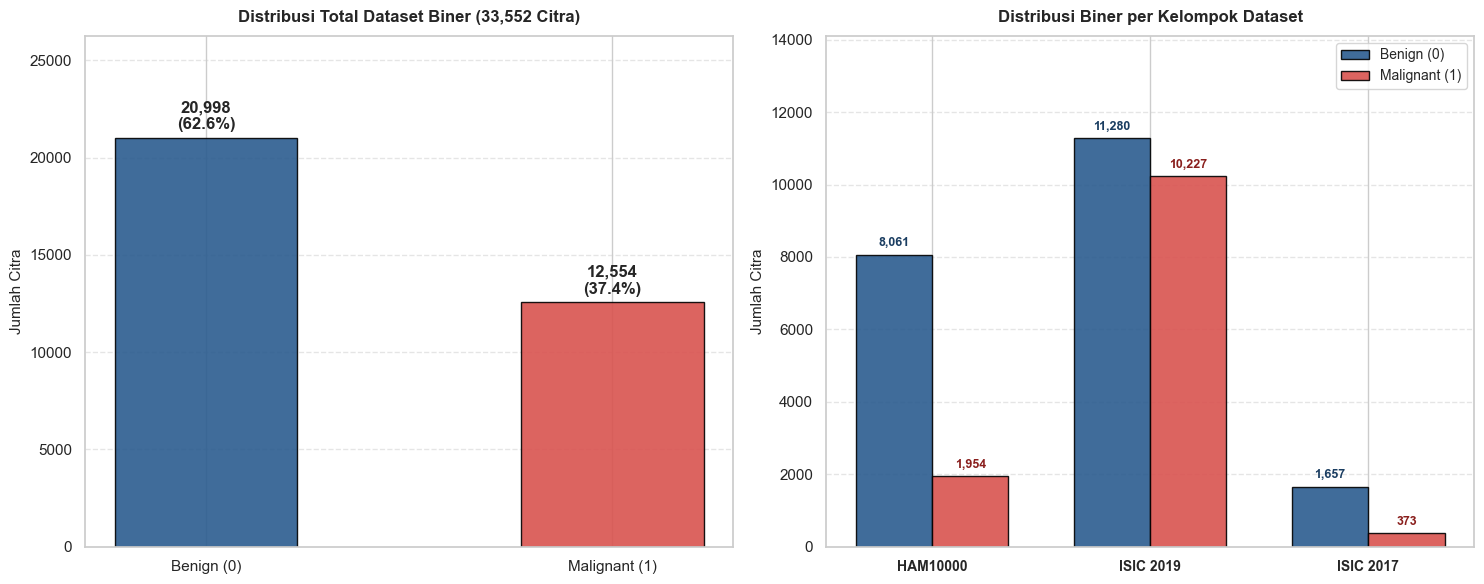

In [26]:
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))

counts_total = [tot_b, tot_m]
labels_total = ['Benign (0)', 'Malignant (1)']
colors_bin = ['#2b5c8f', '#d9534f']

bars_bin = axes2[0].bar(labels_total, counts_total, color=colors_bin, width=0.45, edgecolor='black', alpha=0.9)
axes2[0].set_title(f"Distribusi Total Dataset Biner ({tot_all:,} Citra)", fontsize=12, fontweight='bold', pad=10)
axes2[0].set_ylabel("Jumlah Citra", fontsize=11)
axes2[0].set_ylim(0, max(counts_total) * 1.25)
axes2[0].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars_bin:
    h = bar.get_height()
    pct = h / tot_all * 100
    axes2[0].text(bar.get_x() + bar.get_width()/2.0, h + 300, f"{int(h):,}\n({pct:.1f}%)", ha='center', va='bottom', fontweight='bold')

fam_ordered = ['HAM10000', 'ISIC 2019', 'ISIC 2017']
x_fam = np.arange(len(fam_ordered))
width_fam = 0.35

b_fams = [(df_binary[(df_binary['dataset_family'] == s) & (df_binary['target_binary'] == 0)]).shape[0] for s in fam_ordered]
m_fams = [(df_binary[(df_binary['dataset_family'] == s) & (df_binary['target_binary'] == 1)]).shape[0] for s in fam_ordered]

rects_b = axes2[1].bar(x_fam - width_fam/2, b_fams, width=width_fam, label='Benign (0)', color='#2b5c8f', edgecolor='black', alpha=0.9)
rects_m = axes2[1].bar(x_fam + width_fam/2, m_fams, width=width_fam, label='Malignant (1)', color='#d9534f', edgecolor='black', alpha=0.9)

max_fam = max(max(b_fams), max(m_fams))
axes2[1].set_ylim(0, max_fam * 1.25)
axes2[1].set_xticks(x_fam)
axes2[1].set_xticklabels(fam_ordered, fontsize=10, fontweight='bold')
axes2[1].set_ylabel("Jumlah Citra", fontsize=11)
axes2[1].set_title("Distribusi Biner per Kelompok Dataset", fontsize=12, fontweight='bold', pad=10)
axes2[1].legend(fontsize=10)
axes2[1].grid(axis='y', linestyle='--', alpha=0.5)

for rect in rects_b:
    h = rect.get_height()
    if h > 0:
        axes2[1].text(rect.get_x() + rect.get_width()/2.0, h + 150, f"{int(h):,}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a3d61')

for rect in rects_m:
    h = rect.get_height()
    if h > 0:
        axes2[1].text(rect.get_x() + rect.get_width()/2.0, h + 150, f"{int(h):,}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='#8a1f1d')

plt.tight_layout()
plt.show()

## Langkah 13: Ekspor Dataset Biner Bersih ke File CSV
Menyimpan seluruh metadata hasil kurasi (33.552 data valid) ke file CSV untuk digunakan pada proses pelatihan model.

In [27]:
output_csv = os.path.join(ROOT, 'dataset_binary_final.csv')
cols_export = ['image_id', 'source', 'original_label', 'unified_class', 'binary_class', 'target_binary', 'filepath']

df_binary[cols_export].to_csv(output_csv, index=False)

print(f"File tersimpan : {output_csv}")
print(f"Total data     : {len(df_binary):,} baris")
print(f"Kolom          : {', '.join(cols_export)}")

display(df_binary[cols_export].head(10))

File tersimpan : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_binary_final.csv
Total data     : 33,552 baris
Kolom          : image_id, source, original_label, unified_class, binary_class, target_binary, filepath


,image_id,source,original_label,unified_class,binary_class,target_binary,filepath
0,ISIC_0000000,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
1,ISIC_0000001,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
2,ISIC_0000002,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
3,ISIC_0000003,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
4,ISIC_0000004,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
5,ISIC_0000006,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
6,ISIC_0000007,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
7,ISIC_0000008,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
8,ISIC_0000009,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
9,ISIC_0000010,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...


## Langkah 14: Pemeriksaan Sampel Visual Citra Asli
Menampilkan contoh foto dermatologi asli untuk memverifikasi tampilan visual lesi Jinak (Benign) dan Ganas (Malignant).

,image_id,source,original_label,unified_class,binary_class,target_binary,filepath
0,ISIC_0000000,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
1,ISIC_0000001,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
2,ISIC_0000003,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
3,ISIC_0000006,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
4,ISIC_0000007,isic_2019_train,NV,NV,Benign,0,C:\Users\ARII\Downloads\Data Understanding Isi...
5,ISIC_0000002,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
6,ISIC_0000004,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
7,ISIC_0000013,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
8,ISIC_0000022,isic_2017_train,melanoma,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...
9,ISIC_0000022_downsampled,isic_2019_train,MEL,MEL,Malignant,1,C:\Users\ARII\Downloads\Data Understanding Isi...


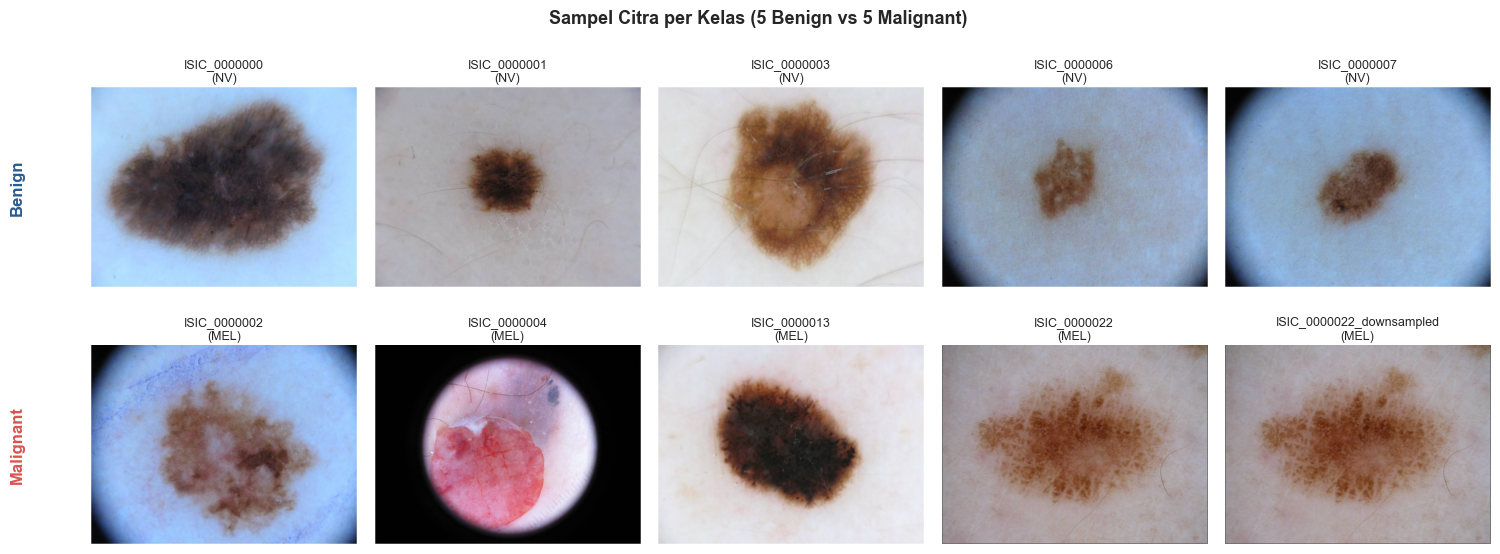

In [28]:
sample_b = df_binary[df_binary['binary_class'] == 'Benign'].head(5)
sample_m = df_binary[df_binary['binary_class'] == 'Malignant'].head(5)
df_samples = pd.concat([sample_b, sample_m], ignore_index=True)

cols_show = ['image_id', 'source', 'original_label', 'unified_class', 'binary_class', 'target_binary', 'filepath']
display(df_samples[cols_show])

fig3, axes3 = plt.subplots(2, 5, figsize=(15, 6))

for row_idx, cls_name in enumerate(['Benign', 'Malignant']):
    subset = df_binary[df_binary['binary_class'] == cls_name].head(5)
    for col_idx, (_, r) in enumerate(subset.iterrows()):
        ax = axes3[row_idx, col_idx]
        if os.path.exists(r['filepath']):
            img = Image.open(r['filepath'])
            ax.imshow(img)
        iid = r['image_id']
        lbl = r['unified_class']
        ax.set_title(f"{iid}\n({lbl})", fontsize=9, pad=4)
        ax.axis('off')
        if col_idx == 0:
            ax.text(-0.25, 0.5, cls_name, transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='center', ha='right', rotation=90,
                    color='#2b5c8f' if cls_name == 'Benign' else '#d9534f')

plt.suptitle("Sampel Citra per Kelas (5 Benign vs 5 Malignant)", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()